In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pickle

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic
from trianglechain import TriangleChain

from msfm.utils import logger, files, scales, power_spectra, parameters, observation
from msi.utils import preprocessing, dataset, input_output
from deep_lss.utils import configuration

2026-02-04 06:53:00.208187: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-04 06:53:00.208220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-04 06:53:00.260723: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-04 06:53:00.406046: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 06:53:07.847188: W tensorflow/compiler/tf2

# v15

In [3]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v15/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v15/extended"

out_dir_base = "/pscratch/sd/a/athomsen/run_files/v15"
# label = "baseline"
label = "base_300k"
# label = "mmd"
# label = "cov"
# label = "sw_64"
# label = "sw_analytical"
# label = "sw_penultimate_100_300k"

### lensing

In [4]:
with_lensing = True
with_clustering = False
with_cross_z = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/lensing/dlss.yaml"
)

26-02-04 06:53:33 configuratio INF   Loaded the config 


### clustering

In [5]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/clustering/dlss.yaml"
# )

### combined

In [6]:
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v15/default/combined/dlss.yaml"
# )

# constants

In [7]:
batch_size = 2**10
# batch_size = 2**6
apply_log = True
standardize = False

# n_steps = 100_000
n_steps = 300_000

out_dir = os.path.join(out_dir_base, "cls/mutual_info/debug")
    
if label is not None:
    out_dir = os.path.join(out_dir, label)
    
os.makedirs(out_dir, exist_ok=True)

print("base_dir = ", base_dir)
print("out_dir = ", out_dir)

base_dir =  /pscratch/sd/a/athomsen/v11desy3/v15/extended
out_dir =  /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/base_300k


# white noise dset

26-02-04 07:16:37 configuratio INF   Loaded the config 
26-02-04 07:16:37 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-02-04 07:16:37 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-02-04 07:16:37 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-02-04 07:16:37 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-02-04 07:16:37 preprocessin INF   Using n_bins = 33 from the msfm config 
26-02-04 07:16:37 preprocessin INF   Loading the pre-binned Cls 
26-02-04 07:16:37 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v15/extended 
26-02-04 07:18:14 input_output INF   Array shapes: 
26-02-04 07:22:42 input_output INF   fiducial/i_example = (

2026-02-04 07:26:58.237474: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


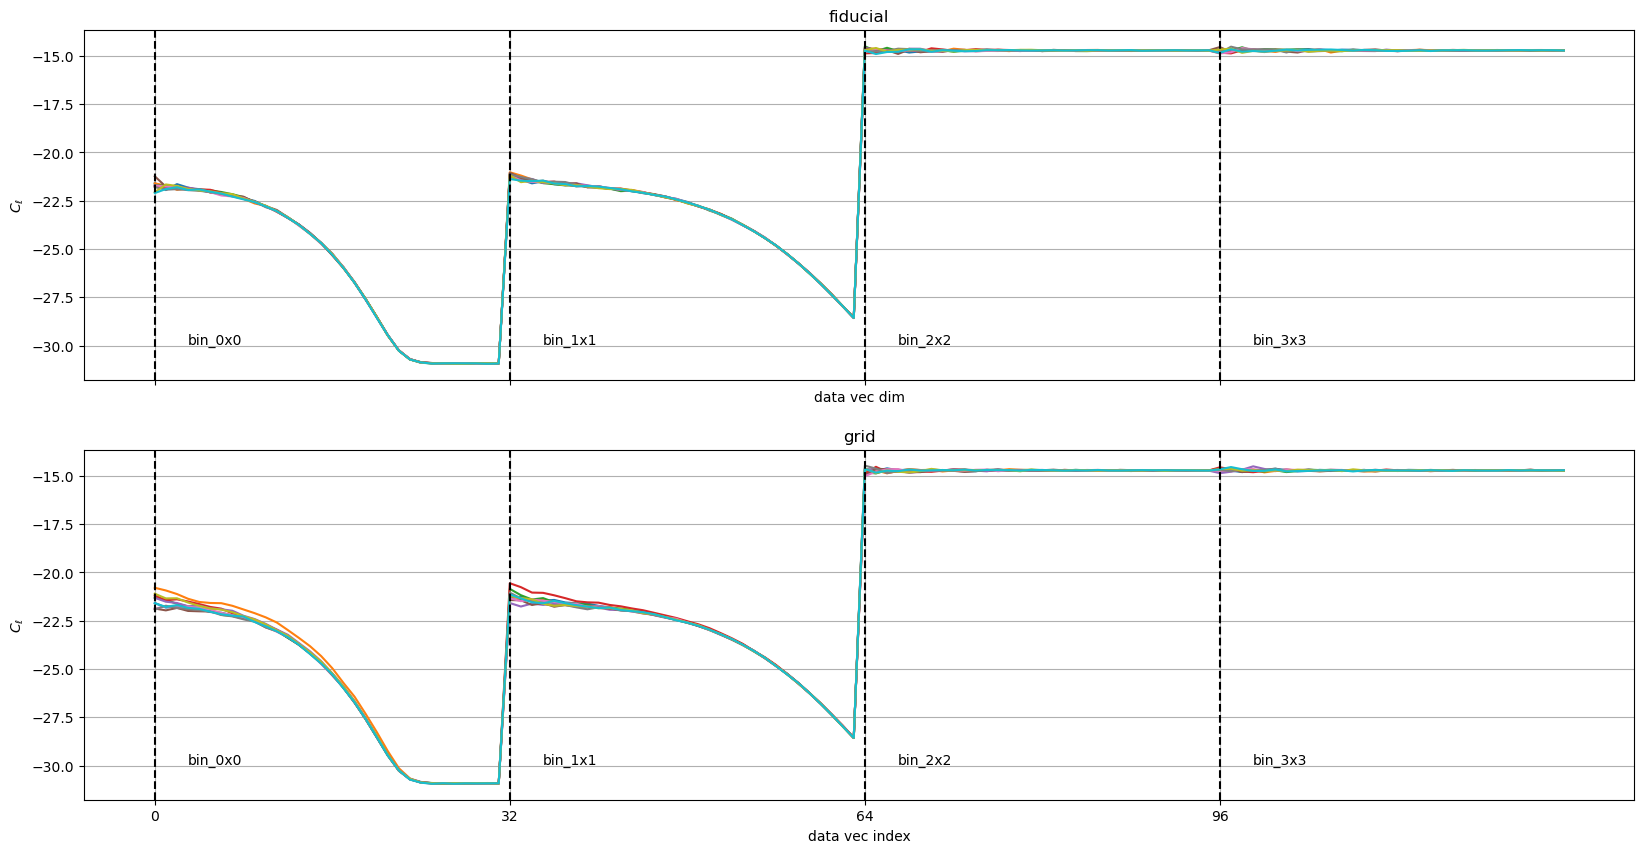

In [8]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # dset
    batch_size=batch_size,
    apply_log=True,
    standardize=False,
)

# functions and global constants

In [9]:
from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization
from deep_lss.nets.mlp import MultiLayerPerceptron

In [10]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = n_params

num_hidden_units = 1024
num_penultimate = 64
# num_layers = 2
num_layers = 4
# dropout_rate = 0.1
dropout_rate = 0.0

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        # num_penultimate=num_penultimate,
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    mlp.summary()
    
    return mlp

In [11]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

# variational lower bound

In [12]:
learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate)

summary_net = get_cl_summary_network()
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    summary_dir=os.path.join(out_dir, "history"),
    # restore_checkpoint=True,
    restore_checkpoint=False,
    # z_bank_size=4*batch_size,
)

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
    # feature regularization
    # z_weight=10,
    z_type="sw",
    # z_type="mmd",
    # z_type="cov",
    # z_layer="penultimate",
    z_layer="last",
)

Model: "multi_layer_perceptron"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer_normalization (Layer  multiple                  256       
 Normalization)                                                  
                                                                 
 dense (Dense)               multiple                  132096    
                                                                 
 dense_1 (Dense)             multiple                  1049600   
                                                                 
 dense_2 (Dense)             multiple                  1049600   
                                                                 
 dense_3 (Dense)             multiple                  1049600   
                                                                 
 output (Dense)              multiple                  6150      
                                            

In [ ]:
train_model(model, eval_every=n_steps//10)

  0%|          | 0/300000 [00:00<?, ?it/s]

26-02-04 07:39:53 grid_model.p WAR   Tracing grid_train_step 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
26-02-04 07:39:55 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
26-02-04 07:39:56 grid_model.p WAR   Tracing grid_train_step 
26-02-04 07:39:56 base_model.p W

2026-02-04 07:39:56.877402: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903
2026-02-04 07:39:58.378347: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8673087870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-04 07:39:58.378363: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-04 07:39:58.387524: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770219598.479906  514851 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
  0%|          | 1108/300000 [00:29<19:40, 253.22it/s]

# save the results

In [ ]:
fidu_cls = out_dict["fidu/cls"]
grid_cls = out_dict["grid/cls/test"]

fidu_preds = model(fidu_cls, training=False).numpy()
grid_preds = model(grid_cls, training=False).numpy()

z_model = tf.keras.Sequential(model.network.layers[:-1])
fidu_z = z_model(fidu_cls, training=False).numpy()
grid_z = z_model(grid_cls, training=False).numpy()

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="fidu/preds", data=fidu_preds)
    
    f.create_dataset(name="grid/z/test", data=grid_z)
    f.create_dataset(name="fidu/z", data=fidu_z)

print(f"Wrote to {pred_file}\n")

In [ ]:
n_summary = grid_preds.shape[-1]

fig, ax = plt.subplots(figsize=(8,2*n_summary), nrows=n_summary)

for i in range(n_summary):
    ax[i].hist(grid_preds[:,i], bins=100, label="default", alpha=0.5)

ax[0].legend(title=f"summary s")

In [ ]:
stop

In [ ]:
# n_z = grid_z.shape[-1]
# # n_z = 10

# fig, ax = plt.subplots(figsize=(8,2*n_z), nrows=n_z, sharex=True)

# for i in range(n_z):
#     ax[i].hist(grid_z[:,i], bins=100, label="default", alpha=0.5)

# ax[0].legend(title=f"features z")

In [ ]:
np.std(grid_preds, axis=0)**2

In [ ]:
np.mean(grid_preds, axis=0)

In [ ]:
plt.hist(

In [ ]:
stop

In [ ]:
grid_z.shape

In [ ]:
fig, ax = plt.subplots()

ax.hist(grid_z[:,14].numpy(), bins=100);

In [ ]:
np.cov(default_z, rowvar=False)

In [ ]:
mmd_z

# compare features

In [ ]:
# default_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/default/preds.h5"
# cov_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/with_z/preds.h5"
# mmd_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/standard=False,log=True,steps=100000/testing/with_z_mmd/preds.h5"

default_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/baseline/preds.h5"
cov_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/z_cov/preds.h5"
mmd_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/lensing/testing/standard=False,log=True,steps=100000/z_mmd/preds.h5"

with h5py.File(default_file, "r") as f:
    default_s = f["grid/preds/test"][:]
    default_z = f["grid/z/test"][:]
    
with h5py.File(cov_file, "r") as f:
    cov_s = f["grid/preds/test"][:]
    cov_z = f["grid/z/test"][:]

with h5py.File(mmd_file, "r") as f:
    mmd_s = f["grid/preds/test"][:]
    mmd_z = f["grid/z/test"][:]


In [ ]:
n_summary = default_s.shape[-1]

fig, ax = plt.subplots(figsize=(8,2*n_summary), nrows=n_summary)

for i in range(n_summary):
    ax[i].hist(default_s[:,i], bins=100, label="default", alpha=0.5)
    ax[i].hist(cov_s[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_s[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"summary s")

In [ ]:
n_z = default_z.shape[-1]
# n_z = 10

fig, ax = plt.subplots(figsize=(8,2*n_z), nrows=n_z)

for i in range(n_z):
    # ax[i].hist(default_z[:,i], bins=100, label="default", alpha=0.5)
    # ax[i].hist(cov_z[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_z[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"feature z")

In [ ]:
n_z = default_z.shape[-1]
# n_z = 10

fig, ax = plt.subplots(figsize=(8,2*n_z), nrows=n_z)

for i in range(n_z):
    # ax[i].hist(default_z[:,i], bins=100, label="default", alpha=0.5)
    # ax[i].hist(cov_z[:,i], bins=100, label="cov", alpha=0.5)
    ax[i].hist(mmd_z[:,i], bins=100, label="mmd", alpha=0.5)

ax[0].legend(title=f"feature z")